In [ ]:
9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0

In [4]:
import pandas as pd

# Load dữ liệu
df = pd.read_csv("titanic_disaster.csv")

# Tạo familySize
df['familySize'] = 1 + df['SibSp'] + df['Parch']

# Tạo biến Alone (đúng theo đề bài)
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 0 else 0)

# Kiểm tra kết quả
print(df[['SibSp', 'Parch', 'familySize', 'Alone']].head(10))
print(df['Alone'].value_counts())


   SibSp  Parch  familySize  Alone
0      1      0           2      0
1      1      0           2      0
2      0      0           1      0
3      1      0           2      0
4      0      0           1      0
5      0      0           1      0
6      0      0           1      0
7      3      1           5      0
8      0      2           3      0
9      1      0           2      0
Alone
0    891
Name: count, dtype: int64


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu
thì thay thế bằng “Unknown”

In [5]:
# Tạo đặc trưng typeCabin
df['typeCabin'] = df['Cabin'].fillna('Unknown').str[0]

# Kiểm tra kết quả
print(df[['Cabin', 'typeCabin']].head(10))
print(df['typeCabin'].value_counts())


  Cabin typeCabin
0   NaN         U
1   C85         C
2   NaN         U
3  C123         C
4   NaN         U
5   NaN         U
6   E46         E
7   NaN         U
8   NaN         U
9   NaN         U
typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.

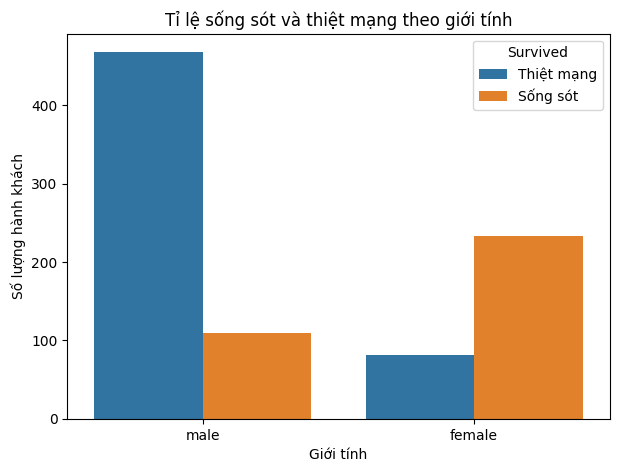

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Tỉ lệ sống sót và thiệt mạng theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Survived', labels=['Thiệt mạng', 'Sống sót'])
plt.show()


13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

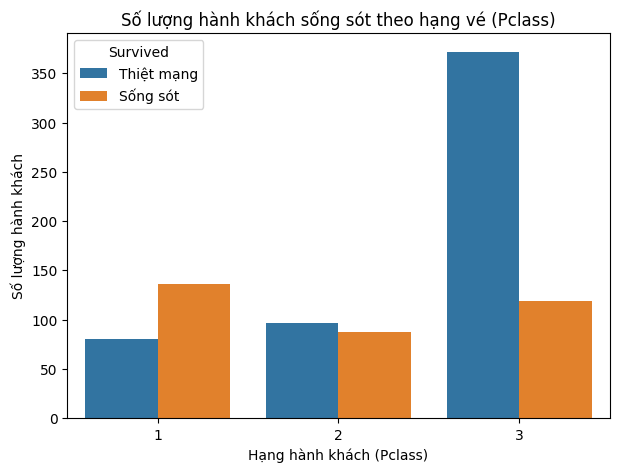

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Số lượng hành khách sống sót theo hạng vé (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Survived', labels=['Thiệt mạng', 'Sống sót'])
plt.show()


14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác


    Age Agegroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult
Agegroup
Adult    553
Teen      70
Kid       69
Older     22
Name: count, dtype: int64


C:\Users\US\AppData\Local\Temp\ipykernel_14900\2115512674.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Agegroup', 'Sex'])['Survived']


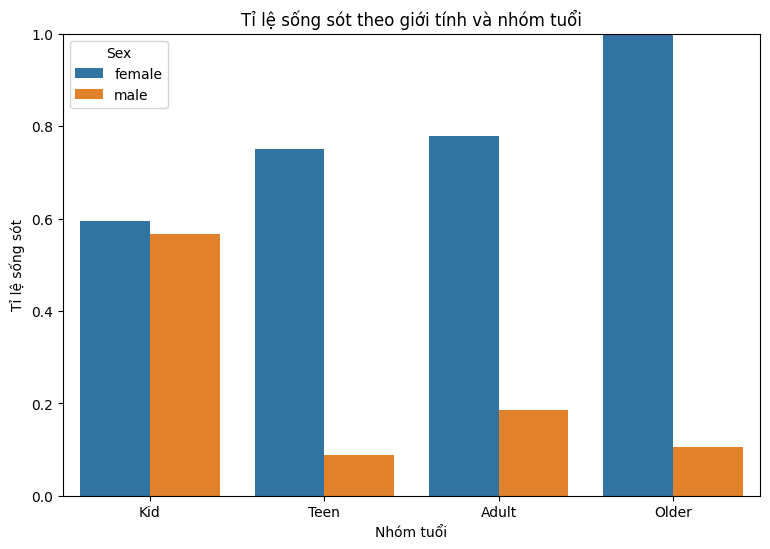

In [23]:
import numpy as np

bins = [0, 12, 18, 60, np.inf]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print(df[['Age', 'Agegroup']].head())
print(df['Agegroup'].value_counts())

survival_age_sex = (
    df.groupby(['Agegroup', 'Sex'])['Survived']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=survival_age_sex,
    x='Agegroup',
    y='Survived',
    hue='Sex',
    order=['Kid', 'Teen', 'Adult', 'Older']
)
plt.title('Tỉ lệ sống sót theo giới tính và nhóm tuổi')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỉ lệ sống sót')
plt.ylim(0, 1)
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

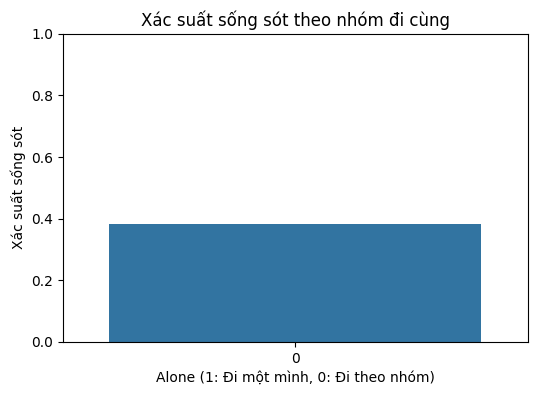

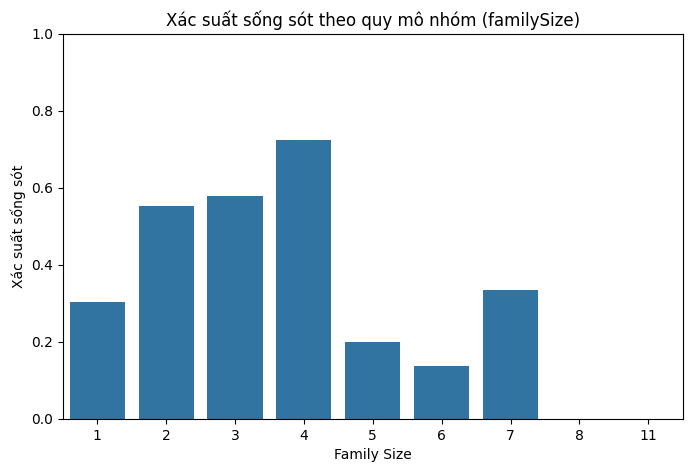

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính xác suất sống sót theo Alone
survival_alone = df.groupby('Alone')['Survived'].mean().reset_index()

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
sns.barplot(data=survival_alone, x='Alone', y='Survived')
plt.title('Xác suất sống sót theo nhóm đi cùng')
plt.xlabel('Alone (1: Đi một mình, 0: Đi theo nhóm)')
plt.ylabel('Xác suất sống sót')
plt.ylim(0, 1)
plt.show()

survival_family = df.groupby('familySize')['Survived'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=survival_family, x='familySize', y='Survived')
plt.title('Xác suất sống sót theo quy mô nhóm (familySize)')
plt.xlabel('Family Size')
plt.ylabel('Xác suất sống sót')
plt.ylim(0, 1)
plt.show()


16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

C:\Users\US\AppData\Local\Temp\ipykernel_14900\56744542.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_fare = df.groupby('FareGroup')['Survived'].mean().reset_index()


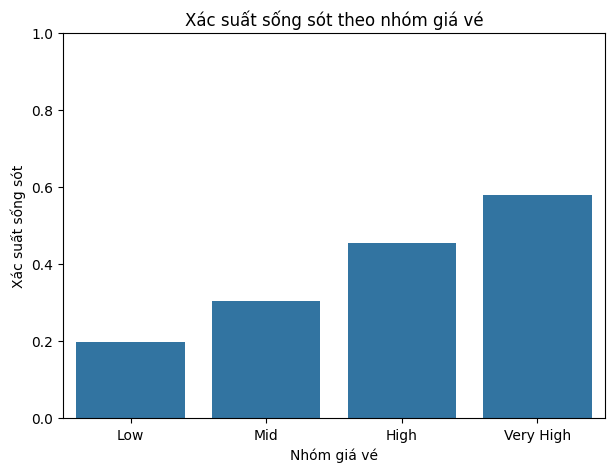

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chia giá vé thành 4 nhóm theo tứ phân vị
df['FareGroup'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Mid', 'High', 'Very High'])

# Tính xác suất sống sót theo nhóm giá vé
survival_fare = df.groupby('FareGroup')['Survived'].mean().reset_index()

# Trực quan hóa
plt.figure(figsize=(7, 5))
sns.barplot(data=survival_fare, x='FareGroup', y='Survived')
plt.title('Xác suất sống sót theo nhóm giá vé')
plt.xlabel('Nhóm giá vé')
plt.ylabel('Xác suất sống sót')
plt.ylim(0, 1)
plt.show()


17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và
cảng sẽ cập bến.

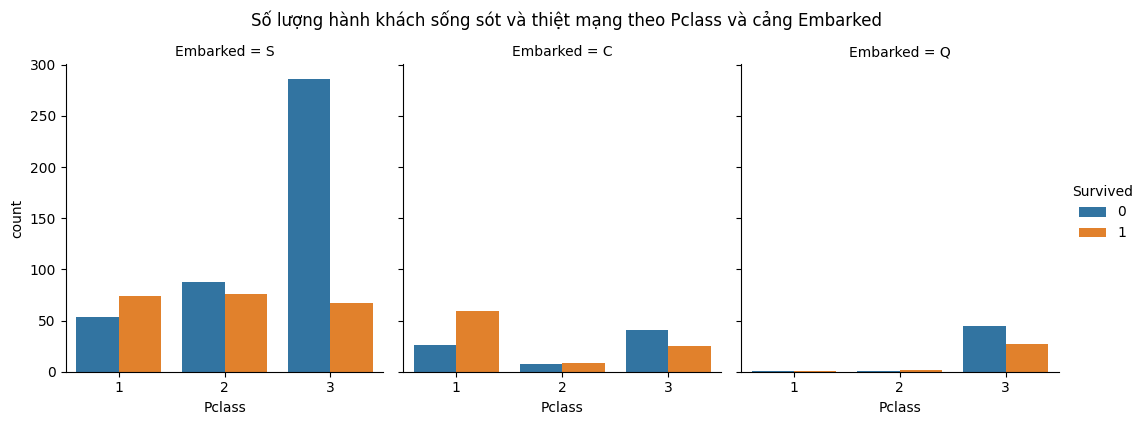

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.catplot(
    data=df,
    x='Pclass',
    hue='Survived',
    col='Embarked',
    kind='count',
    height=4,
    aspect=0.9
)

plt.suptitle(
    'Số lượng hành khách sống sót và thiệt mạng theo Pclass và cảng Embarked',
    y=1.05
)
plt.show()
